# Transformer × NF-CSE-CIC-IDS2018-V2 — Intrusion Detection
**Workflow:** Load parquet → Robust Clean → PCA → StandardScaler → KBins → [Transformer] → CrossEntropyLoss → Metrics


In [ ]:
import os, math, warnings, gc, random
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

SEED = 42
def seed_everything(seed=42):
    random.seed(seed); os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
seed_everything(SEED)

# Tự động phát hiện GPU nếu có
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cpu


In [ ]:
# ====== CẤU HÌNH ======
DATA_PATH = r"C:\Users\ADMIN\Desktop\Dữ Liệu\IDS2018-v2\NF-CSE-CIC-IDS2018-V2.parquet"
LABEL_COL   = 'Label'
N_PCA       = 20
N_BINS      = 32
BATCH_SIZE  = 128
# num_workers=0: bắt buộc trên Windows khi chạy ngoài if __name__=='__main__'
NUM_WORKERS = 0
EPOCHS      = 10
LR          = 1e-3
D_MODEL     = 32
N_HEADS     = 2
N_PERSIST   = 4
LMM_HIDDEN  = 64
OUTLIER_TH  = 3.0
PRE_BATCH   = 50000


## 1. Load parquet + xử lý cột constant & log transform

In [ ]:
df = pd.read_parquet(DATA_PATH)
print('Raw shape:', df.shape)

std_series = df.std(numeric_only=True)
const_cols = std_series[std_series == 0].index.tolist()
print('Cột số constant:', const_cols)

if 'SRC_TO_DST_SECOND_BYTES' in df.columns:
    df['SRC_TO_DST_SECOND_BYTES_LOG'] = np.log1p(df['SRC_TO_DST_SECOND_BYTES'])
    df = df.drop(columns=['SRC_TO_DST_SECOND_BYTES'])
    print('✅ Đã log-transform SRC_TO_DST_SECOND_BYTES')

# ====== ĐA NHÃN: dùng cột Attack (fallback Label) ======
LABEL_MULTI = 'Attack' if 'Attack' in df.columns else 'Label'
print(f'Dùng cột nhãn: {LABEL_MULTI}')

drop_cols = [c for c in ['Label', 'Attack'] + const_cols if c in df.columns]
numerical_columns = [c for c in df.columns
                     if c not in drop_cols and np.issubdtype(df[c].dtype, np.number)]

X = df[numerical_columns].copy()
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df[LABEL_MULTI].astype(str).values).astype(np.int64)
CLASS_NAMES = list(label_encoder.classes_)
print(f'X shape: {X.shape} | y shape: {y.shape}')
print(f'Số lớp: {len(CLASS_NAMES)}')
print('Danh sách nhãn:')
for i, name in enumerate(CLASS_NAMES):
    cnt = int((y == i).sum())
    print(f'  {i:2d} - {name}: {cnt:,}')


FileNotFoundError: [Errno 2] No such file or directory: 'C:/path/to/NF-CSE-CIC-IDS2018-V2.parquet'

## 2. Split train / val / test (stratified)

In [ ]:
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=SEED)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=2/3, stratify=y_tmp, random_state=SEED)
print(f'Train: {X_tr.shape} | Val: {X_val.shape} | Test: {X_te.shape}')
del X, X_tmp, y_tmp, df; gc.collect()

Train: (11990800, 40) | Val: (1712971, 40) | Test: (3425944, 40)


0

## 3. Robust preprocessing theo batch (NaN / Inf / Outlier)

In [ ]:
def robust_preprocess_large_data(X_train, X_val, X_test,
                                  batch_size=50000, outlier_threshold=3.0):
    print('🔄 Bắt đầu xử lý dữ liệu nâng cao...')
    if hasattr(X_train, 'values'): X_train = X_train.values
    if hasattr(X_val, 'values'):   X_val   = X_val.values
    if hasattr(X_test, 'values'):  X_test  = X_test.values
    X_train = X_train.astype(np.float32)
    X_val   = X_val.astype(np.float32)
    X_test  = X_test.astype(np.float32)

    sample_size = min(100000, len(X_train))
    idx = np.random.choice(len(X_train), sample_size, replace=False)
    X_sample = X_train[idx].copy()
    medians = np.nanmedian(X_sample, axis=0)
    stds    = np.nanstd(X_sample, axis=0)
    stds[stds == 0] = 1.0
    print(f'  Stats từ {sample_size} mẫu')

    def process(batch):
        batch = batch.copy()
        batch[np.isinf(batch)] = np.nan
        for col in range(batch.shape[1]):
            cd = batch[:, col]; med = medians[col]; sd = stds[col]
            z = np.abs((cd - med) / sd)
            mask = z > outlier_threshold
            if mask.any(): batch[mask, col] = med
            nan_mask = np.isnan(batch[:, col])
            if nan_mask.any(): batch[nan_mask, col] = med
        return np.clip(batch, -1e6, 1e6)

    def by_batch(arr, name):
        n = len(arr); nb = int(np.ceil(n / batch_size)); out = []
        for i in range(nb):
            s, e = i*batch_size, min((i+1)*batch_size, n)
            out.append(process(arr[s:e]))
            if (i+1) % 20 == 0 or (i+1) == nb:
                print(f'  {name}: {e:,}/{n:,}')
        return np.vstack(out)

    Xtr = by_batch(X_train, 'train')
    Xva = by_batch(X_val,   'val  ')
    Xte = by_batch(X_test,  'test ')
    print(f'✅ NaN train={np.isnan(Xtr).any()} | Inf train={np.isinf(Xtr).any()}')
    return Xtr, Xva, Xte

X_tr_p, X_val_p, X_te_p = robust_preprocess_large_data(
    X_tr, X_val, X_te, batch_size=PRE_BATCH, outlier_threshold=OUTLIER_TH)
del X_tr, X_val, X_te; gc.collect()

🔄 Bắt đầu xử lý dữ liệu nâng cao...
  Stats từ 100000 mẫu
  train: 1,000,000/11,990,800
  train: 2,000,000/11,990,800
  train: 3,000,000/11,990,800
  train: 4,000,000/11,990,800
  train: 5,000,000/11,990,800
  train: 6,000,000/11,990,800
  train: 7,000,000/11,990,800
  train: 8,000,000/11,990,800
  train: 9,000,000/11,990,800
  train: 10,000,000/11,990,800
  train: 11,000,000/11,990,800
  train: 11,990,800/11,990,800
  val  : 1,000,000/1,712,971
  val  : 1,712,971/1,712,971
  test : 1,000,000/3,425,944
  test : 2,000,000/3,425,944
  test : 3,000,000/3,425,944
  test : 3,425,944/3,425,944
✅ NaN train=False | Inf train=False


0

## 4. PCA giảm chiều (40 → 20)

In [ ]:
print('🧠 Áp dụng PCA...')
pca = PCA(n_components=N_PCA, random_state=SEED)
X_tr_pca  = pca.fit_transform(X_tr_p)
X_val_pca = pca.transform(X_val_p)
X_te_pca  = pca.transform(X_te_p)

evr = pca.explained_variance_ratio_
print(f'Shape sau PCA: {X_tr_pca.shape}')
print(f'Tổng variance giữ được: {evr.sum()*100:.2f}%')
print(f'Cumulative: {np.cumsum(evr)}')
del X_tr_p, X_val_p, X_te_p; gc.collect()

🧠 Áp dụng PCA...
Shape sau PCA: (11990800, 20)
Tổng variance giữ được: 100.00%
Cumulative: [0.75140727 0.91402227 0.9553515  0.99379015 0.99640596 0.9980492
 0.9990372  0.9998877  0.99994326 0.99999464 0.9999987  0.9999996
 0.99999976 0.9999998  0.9999999  0.9999999  0.9999999  0.9999999
 0.9999999  0.9999999 ]


0

## 5. StandardScaler + Tokenize bằng KBinsDiscretizer

In [ ]:
scaler = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_tr_pca)
X_val_sc = scaler.transform(X_val_pca)
X_te_sc  = scaler.transform(X_te_pca)

kbd = KBinsDiscretizer(n_bins=N_BINS, encode='ordinal', strategy='quantile')
tok_tr  = kbd.fit_transform(X_tr_sc).astype(np.int64)
tok_val = kbd.transform(X_val_sc).astype(np.int64)
tok_te  = kbd.transform(X_te_sc).astype(np.int64)

ordered_vocab = [int(max(tok_tr[:, i].max(), tok_val[:, i].max(), tok_te[:, i].max())) + 2
                 for i in range(tok_tr.shape[1])]
SEQ_LEN_FINAL = tok_tr.shape[1]
N_CLASSES = len(np.unique(y_tr))
print(f'Token shape: {tok_tr.shape} | Vocab/feature: {ordered_vocab}')
print(f'N_CLASSES: {N_CLASSES}')

Token shape: (11990800, 20) | Vocab/feature: [33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33]
N_CLASSES: 15


## 6. Dataset & DataLoader

In [ ]:
class TokenDS(Dataset):
    def __init__(self, X_tok, y):
        self.X = torch.from_numpy(X_tok).long()
        self.y = torch.from_numpy(y).long()
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_ds = TokenDS(tok_tr,  y_tr)
val_ds   = TokenDS(tok_val, y_val)
test_ds  = TokenDS(tok_te,  y_te)

# num_workers=0  → Windows-safe (không cần spawn process)
# pin_memory=False → chỉ có lợi khi dùng GPU; ở đây dùng CPU
# persistent_workers bị xóa (chỉ hợp lệ khi num_workers > 0)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True,
                          num_workers=NUM_WORKERS, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=False)


## 7. Transformer Encoder — Classifier
Stack `TransformerEncoderLayer` (multi-head self-attention + FFN) trên chuỗi feature-token, mean-pool → MLP head.

In [ ]:
class FeatureEmbedding(nn.Module):
    def __init__(self, vocab_sizes, d_model):
        super().__init__()
        self.embs = nn.ModuleList([nn.Embedding(v, d_model) for v in vocab_sizes])
        self.pos  = nn.Embedding(len(vocab_sizes), d_model)
        self.norm = nn.LayerNorm(d_model)
    def forward(self, x):
        B, L = x.shape
        tok = torch.stack([self.embs[i](x[:, i]) for i in range(L)], dim=1)
        pos_ids = torch.arange(L, device=x.device).unsqueeze(0).expand(B, L)
        return self.norm(tok + self.pos(pos_ids))


class TransformerClassifier(nn.Module):
    """x -> Embed+PE -> N x TransformerEncoderLayer -> mean pool -> MLP head."""
    def __init__(self, vocab_sizes, n_classes,
                 d_model=64, n_heads=4, n_layers=4,
                 dim_ff=256, dropout=0.2):
        super().__init__()
        self.embed = FeatureEmbedding(vocab_sizes, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=dim_ff, dropout=dropout,
            activation='gelu', batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model, n_classes))
    def forward(self, x):
        h = self.embed(x)
        h = self.encoder(h)
        return self.head(h.mean(dim=1))


N_LAYERS = 4
DIM_FF   = 256
DROPOUT  = 0.2

model = TransformerClassifier(
    ordered_vocab, N_CLASSES,
    d_model=D_MODEL, n_heads=N_HEADS,
    n_layers=N_LAYERS, dim_ff=DIM_FF, dropout=DROPOUT
).to(DEVICE)
print(f'Transformer params: {sum(p.numel() for p in model.parameters()):,}')


Transformer params: 107,535


## 8. Train

In [ ]:
def evaluate(model, loader):
    model.eval(); all_p, all_t = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            all_p.append(logits.argmax(-1).cpu().numpy())
            all_t.append(yb.numpy())
    p = np.concatenate(all_p); t = np.concatenate(all_t)
    return {'acc': accuracy_score(t, p),
            'f1':  f1_score(t, p, average='weighted', zero_division=0),
            'prec':precision_score(t, p, average='weighted', zero_division=0),
            'rec': recall_score(t, p, average='weighted', zero_division=0),
            'pred': p, 'true': t}

class_counts = np.bincount(y_tr, minlength=N_CLASSES)
weights = torch.tensor(len(y_tr) / (N_CLASSES * np.maximum(class_counts, 1)),
                       dtype=torch.float32, device=DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = []
for epoch in range(1, EPOCHS + 1):
    model.train(); losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        losses.append(loss.item())
    scheduler.step()
    m = evaluate(model, val_loader)
    history.append({'epoch': epoch, 'loss': np.mean(losses),
                    **{k: m[k] for k in ['acc','f1','prec','rec']}})
    print(f'[Epoch {epoch}/{EPOCHS}] loss={np.mean(losses):.4f} | '
          f'acc={m["acc"]:.4f} | f1={m["f1"]:.4f} | '
          f'prec={m["prec"]:.4f} | rec={m["rec"]:.4f}')

[Epoch 1/3] loss=0.3151 | acc=0.5401 | f1=0.6815 | prec=0.9898 | rec=0.5401
[Epoch 2/3] loss=0.2399 | acc=0.9824 | f1=0.9851 | prec=0.9884 | rec=0.9824
[Epoch 3/3] loss=0.2224 | acc=0.5461 | f1=0.6875 | prec=0.9913 | rec=0.5461


## 9. Đánh giá trên tập TEST + Confusion Matrix


===== FINAL TEST METRICS =====
Accuracy   : 0.5471
F1 (weighted): 0.6885
F1 (macro)   : 0.7172
Precision  : 0.9913
Recall     : 0.5471

----- Classification Report -----
                          precision    recall  f1-score   support

                  Benign     0.9990    0.4871    0.6549   3020338
                     Bot     0.9898    0.9995    0.9946      5607
        Brute Force -Web     0.1555    0.1352    0.1446       429
        Brute Force -XSS     0.7419    0.1243    0.2130       185
        DDOS attack-HOIC     0.9966    1.0000    0.9983    213376
    DDOS attack-LOIC-UDP     0.8004    0.9597    0.8728       422
  DDoS attacks-LOIC-HTTP     0.9736    0.9999    0.9866     41415
   DoS attacks-GoldenEye     0.9456    0.9686    0.9570      5545
        DoS attacks-Hulk     0.9919    0.9984    0.9951     86529
DoS attacks-SlowHTTPTest     0.9965    1.0000    0.9982      2823
   DoS attacks-Slowloris     0.8515    1.0000    0.9198      1903
          FTP-BruteForce     0.9965 

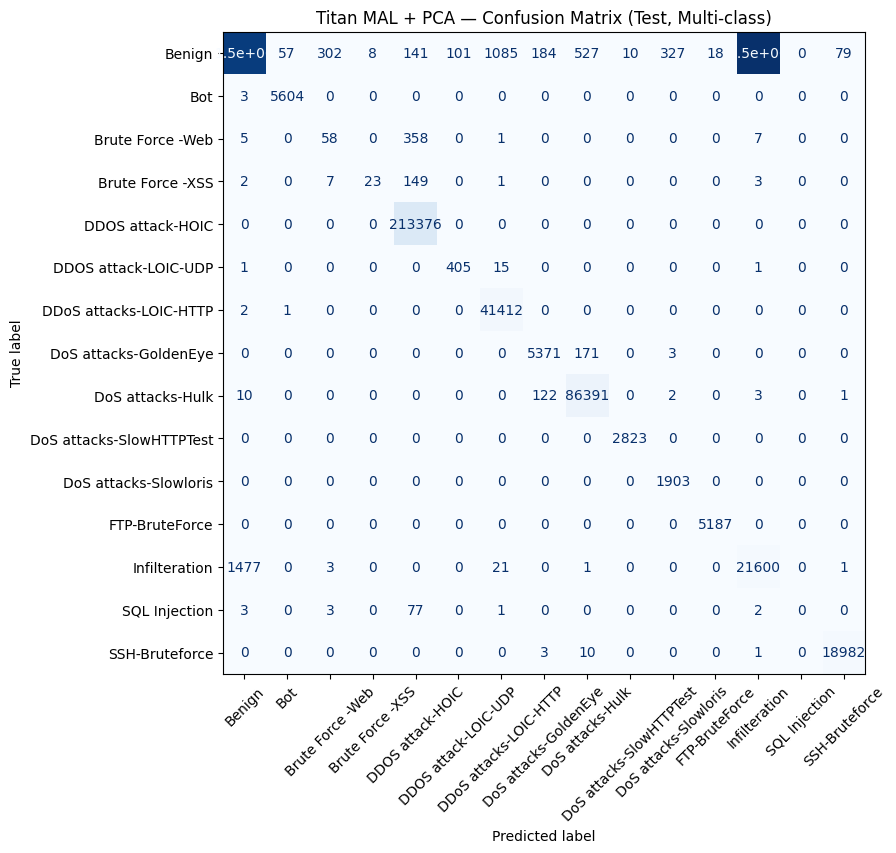

In [ ]:
m = evaluate(model, test_loader)
print('\n===== FINAL TEST METRICS =====')
print(f'Accuracy   : {m["acc"]:.4f}')
print(f'F1 (weighted): {m["f1"]:.4f}')
print(f'F1 (macro)   : {f1_score(m["true"], m["pred"], average="macro", zero_division=0):.4f}')
print(f'Precision  : {m["prec"]:.4f}')
print(f'Recall     : {m["rec"]:.4f}')
print('\n----- Classification Report -----')
print(classification_report(m['true'], m['pred'], target_names=CLASS_NAMES, zero_division=0, digits=4))

labels_idx = list(range(len(CLASS_NAMES)))
cm = confusion_matrix(m['true'], m['pred'], labels=labels_idx)
size = max(6, len(CLASS_NAMES) * 0.6)
fig, ax = plt.subplots(figsize=(size, size))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
plt.title('Titan MAL + PCA — Confusion Matrix (Test, Multi-class)')
plt.tight_layout(); plt.show()
